In [64]:
import pandas as pd

df_pats = pd.concat([pd.read_csv("imputation_results_by_patient_MAR.csv"), 
                     pd.read_csv("imputation_results_by_patient_MNAR.csv")], ignore_index=True)

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# Agrupamentos
# ======================
df_grouped = (
    df_pats
    .groupby(['mechanism', 'patient', 'missing_rate', 'imputer'])['mean_rmse']
    .mean()
    .reset_index()
)

df_memory = (
    df_pats
    .groupby(['mechanism', 'patient', 'imputer'])['memory']
    .mean()
    .reset_index()
)

df_grouped['mechanism_label'] = df_grouped['mechanism'].map(mec_labels)
df_memory['mechanism_label'] = df_memory['mechanism'].map(mec_labels)

# ======================
# Ordens
# ======================
order_mec = ['MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']
order_imputers = [
    'mean',
    'reg_opt_00001',
    'tree_gp_10000',
    'tree_ad_gp_10000',
    'mlp_opt_0001'
]

# ======================
# Labels bonitos dos imputers
# ======================
new_labels = {
    'mean': 'Mean',
    'reg_opt_00001': 'LR',
    'tree_gp_10000': 'HT',
    'tree_ad_gp_10000': 'HAT',
    'mlp_opt_0001': 'MLP',
}
pretty_imputers = [new_labels[i] for i in order_imputers]

# ======================
# Labels LaTeX dos mechanisms
# ======================
mec_labels = {}
for mec in order_mec:
    base, sub = mec.split("_", 1)
    mec_labels[mec] = rf"{base}$_{{{sub.upper()}}}$"


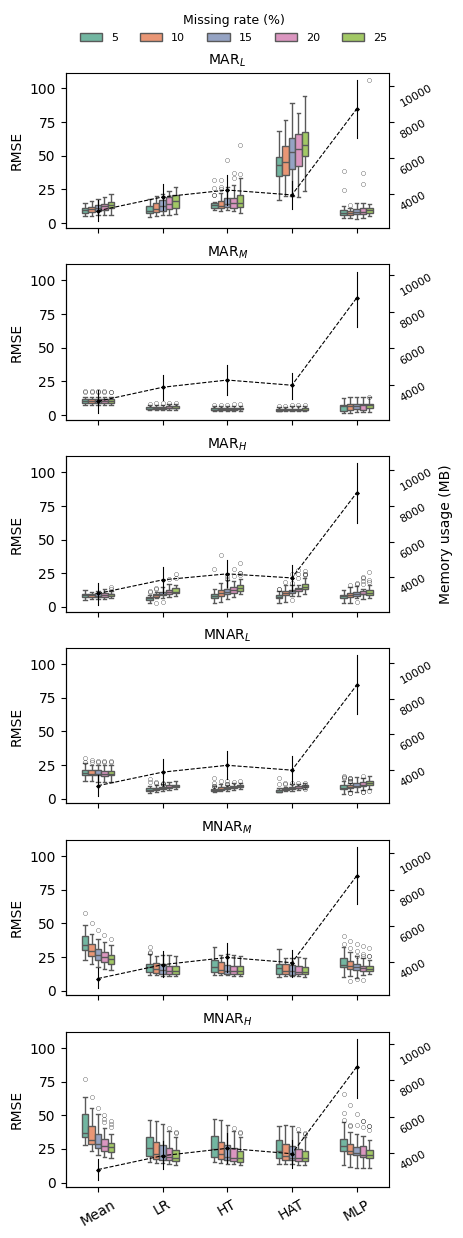

In [ ]:

# ======================
# Catplot vertical
# ======================
g = sns.catplot(
    data=df_grouped,
    x='imputer',
    y='mean_rmse',
    hue='missing_rate',
    row='mechanism_label',
    row_order=[mec_labels[mec] for mec in order_mec],
    order=order_imputers,
    kind='box',
    palette='Set2',
    width=0.5,
    height=2.2,
    aspect=4,
    flierprops=dict(
        marker='o',
        markersize=3,
        markeredgewidth=0.2,
        markeredgecolor='black'
    )
)

# ======================
# Segundo eixo Y (memória)
# ======================
axes = g.axes.flat

for i, (ax, mechanism) in enumerate(zip(axes, order_mec)):
    ax2 = ax.twinx()

    sns.pointplot(
        data=df_memory[df_memory['mechanism'] == mechanism],
        x='imputer',
        y='memory',
        color='black',
        markers='D',
        linestyles='--',
        linewidth=0.8,
        ax=ax2,
        
    )

    ax2.tick_params(axis='y', labelrotation=30, labelsize=8, labelcolor='black')

    if i == 2:
        ax2.set_ylabel('Memory usage (MB)')
    else:
        ax2.set_ylabel('')

# ======================
# Legenda (missing rate) em cima — versão robusta
# ======================
handles = g._legend_data.values()
labels = g._legend_data.keys()

g._legend.remove()

g.figure.legend(
    handles,
    labels,
    title="Missing Rate (%)",
    loc='upper center',
    ncol=len(labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.03),
    fontsize=8,
    title_fontsize=9
)

# ======================
# Eixos e títulos
# ======================
g.set_axis_labels("", "RMSE")
g.set_titles(row_template="{row_name}", size=10)

for ax in g.axes.flat:
    ax.set_xticks(range(len(order_imputers)))
    ax.set_xticklabels(pretty_imputers, rotation=30)

# ======================
# Tamanho e salvamento
# ======================
g.figure.set_size_inches(4, 12)
plt.savefig("Plots/boxplot_imputers_vertical.png", bbox_inches='tight', dpi=300)
plt.show()


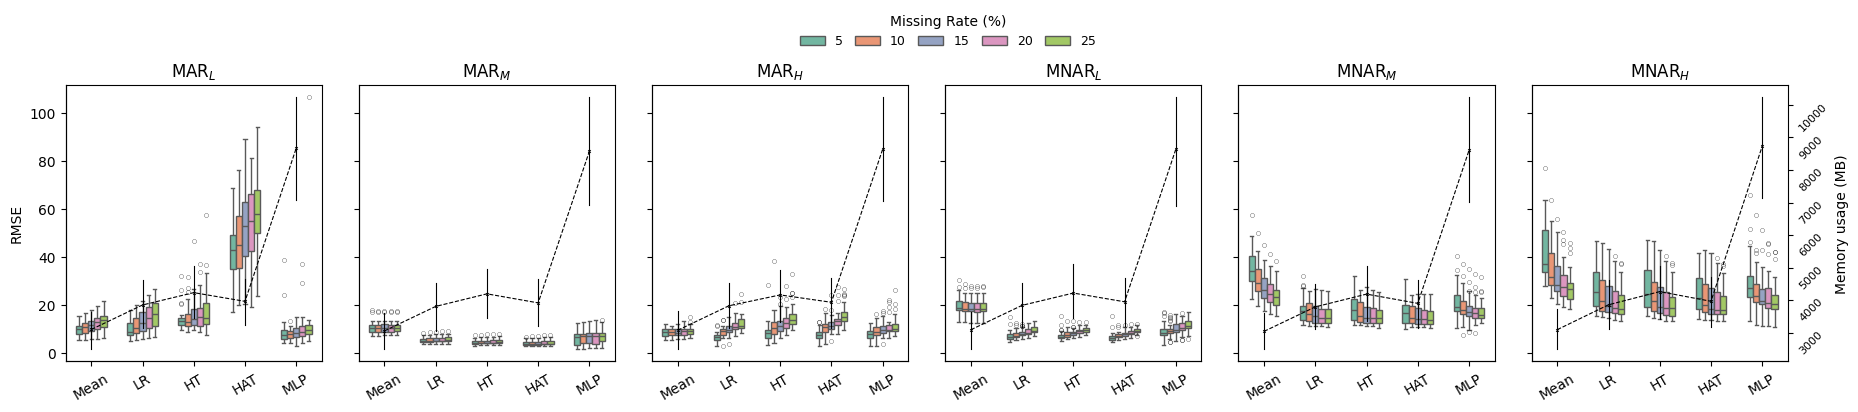

In [77]:

# ======================
# Catplot horizontal
# ======================
g = sns.catplot(
    data=df_grouped,
    x='imputer',
    y='mean_rmse',
    hue='missing_rate',
    col='mechanism',
    col_order=order_mec,
    order=order_imputers,
    kind='box',
    palette='Set2',
    width=0.6,
    height=3.0,
    aspect=1.1,
    flierprops=dict(
        marker='o',
        markersize=3,
        markeredgewidth=0.2,
        markeredgecolor='black'
    )
)

# ======================
# Segundo eixo Y (memória)
# ======================
axes = g.axes.flat

for i, (ax, mechanism) in enumerate(zip(axes, order_mec)):
    ax2 = ax.twinx()

    sns.pointplot(
        data=df_memory[df_memory['mechanism'] == mechanism],
        x='imputer',
        y='memory',
        color='black',
        markers='x',
        linestyles='--',
        linewidth=0.8,
        ax=ax2,
        # errorbar=None
    )

    # eixo de memória só no último painel (direita)
    if i == len(order_mec) - 1:
        ax2.set_ylabel('Memory usage (MB)')
        ax2.tick_params(axis='y', labelrotation=45, labelsize=8, labelcolor='black')
    else:
        ax2.set_ylabel('')
        ax2.set_yticks([])
        ax2.spines['right'].set_visible(True)

# ======================
# Legenda do missing rate em cima
# ======================
handles = g._legend_data.values()
labels = g._legend_data.keys()

g._legend.remove()

g.figure.legend(
    handles,
    labels,
    title="Missing Rate (%)",
    loc='upper center',
    ncol=len(labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.09),
    fontsize=9,
    title_fontsize=10,
    columnspacing=1.0
)

# ======================
# Eixos e títulos
# ======================
g.set_axis_labels("", "RMSE")
g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_xticks(range(len(order_imputers)))
    ax.set_xticklabels(pretty_imputers, rotation=30)

    mec = ax.get_title()
    ax.set_title(mec_labels.get(mec, mec))

# ======================
# Tamanho e salvamento
# ======================
g.figure.set_size_inches(19, 4)
plt.savefig(
    "Plots/boxplot_imputers_horizontal.png",
    bbox_inches='tight',
    dpi=300
)
plt.show()
